##### load the libraries

In [8]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

##### Load the IMDB dataset

In [9]:
vocab_size = 10000
max_length = 500

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print(X_train.shape)
print(X_test.shape)

(25000,)
(25000,)


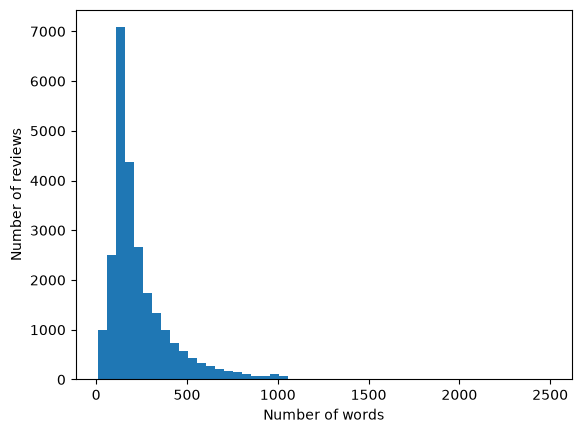

In [6]:
import matplotlib.pyplot as plt

review_lengths = [len(review) for review in X_train]

plt.hist(review_lengths, bins=50)
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.show()

In [7]:
import numpy as np

review_lengths = [len(review) for review in X_train]

print("90th percentile:", np.percentile(review_lengths, 90))
print("95th percentile:", np.percentile(review_lengths, 95))
print("99th percentile:", np.percentile(review_lengths, 99))

90th percentile: 467.0
95th percentile: 610.0
99th percentile: 926.0


##### Pad the reviews as the reviews have different lengths, so make them all 500 words

In [10]:
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print(X_train.shape)
print(X_test.shape)

(25000, 500)
(25000, 500)


##### Build a simple RNN Model

In [11]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    SimpleRNN(128, activation="tanh"),  # tanh keeps activations bounded [-1, 1]
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##### Compile the model

In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

##### Train the model

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.5648 - loss: 0.6762 - val_accuracy: 0.5988 - val_loss: 0.6598
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.6805 - loss: 0.6077 - val_accuracy: 0.6900 - val_loss: 0.5810
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step - accuracy: 0.7265 - loss: 0.5360 - val_accuracy: 0.6830 - val_loss: 0.5939
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.7724 - loss: 0.4776 - val_accuracy: 0.6856 - val_loss: 0.5915
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.7585 - loss: 0.4826 - val_accuracy: 0.6588 - val_loss: 0.6485


##### Evaluate the mode

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6549 - loss: 0.6460
Test Accuracy: 0.6549


##### Save the model

In [17]:
model.save("../models/imdb_rnn.keras")